### Загрузка данных

библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

фаил

In [2]:
df = pd.read_csv('train.csv')

### Знакомство с датасетом

Определяем количество строк и столбцов

In [3]:
df.shape

(891, 12)

Выводим названия всех столбцов

In [4]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

Смотрим типы данных столбцов

In [5]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


 ### Анализ пассажиров

Количество пассажиров каждого класса

In [6]:
df['Pclass'].value_counts().sort_index()

,count
Pclass,
1,216
2,184
3,491


Количество мужчин и женщин

In [7]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


Разделяем пассажиров на возрастные группы

In [8]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Молодые (19-35)', 'Взрослые (36-60)', 'Пожилые (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df['AgeGroup'].value_counts(dropna=False)

,count
AgeGroup,
Молодые (19-35),366
Взрослые (36-60),209
NaN,177
Дети (0-12),68
Подростки (13-18),45
Пожилые (60+),26


Средний возраст пассажиров

In [9]:
round(df['Age'].mean(),2)

np.float64(29.7)

Медианный возраст пассажиров

In [10]:
 df['Age'].median()

28.0

Средняя стоимость билета

In [11]:
round(df['Fare'].mean(), 2)

np.float64(32.2)

### Сравнение пассажиров разных классов

Средняя стоимость билета для 1, 2 и 3 классов

In [12]:
round(df.groupby('Pclass')['Fare'].mean(),2)

,Fare
Pclass,
1,84.15
2,20.66
3,13.68


Средний возраст пассажиров разных классов

In [13]:
round(df.groupby('Pclass')['Age'].mean(), 2)


,Age
Pclass,
1,38.23
2,29.88
3,25.14


Количество мужчин и женщин в каждом классе

In [14]:
 df.groupby(['Pclass', 'Sex']).size().unstack()

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


В каком классе было больше всего пассажиров

In [15]:
max_class = df['Pclass'].value_counts().idxmax()
{max_class}

{np.int64(3)}

Небольшой вывод о различиях между классами

Вывод: Пассажиры 1-го класса платили за билеты в несколько раз больше и были в среднем старше. 3-й класс был самым многочисленным и включал больше мужчин, при этом средняя стоимость билета там была минимальной.

 Самый дорогой билет: класс, возраст, пол и факт выживания

In [16]:
idx_max_fare = df['Fare'].idxmax()
most_expensive = df.loc[idx_max_fare, ['Pclass', 'Age', 'Sex', 'Survived', 'Fare']]
print( most_expensive)

Pclass             1
Age             35.0
Sex           female
Survived           1
Fare        512.3292
Name: 258, dtype: object


### Анализ выживаемости

Общее количество выживших (1) и погибших (0)

In [17]:
 df['Survived'].value_counts()

,count
Survived,
0,549
1,342


Сравнение выживаемости мужчин и женщин

In [18]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()
round(survival_by_sex, 3)

,Survived
Sex,
female,0.742
male,0.189


Выживаемость мужчин и женщин для каждого класса

In [19]:
survival_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
round(survival_by_class_sex, 3)

Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


Группа пассажиров с наибольшей долей выживших

In [20]:
best_survival_group = df.groupby(['Pclass', 'Sex'])['Survived'].mean().idxmax()
{best_survival_group[0]}, {best_survival_group[1]}

({np.int64(1)}, {'female'})

 Визуализация

График количества пассажиров по классам

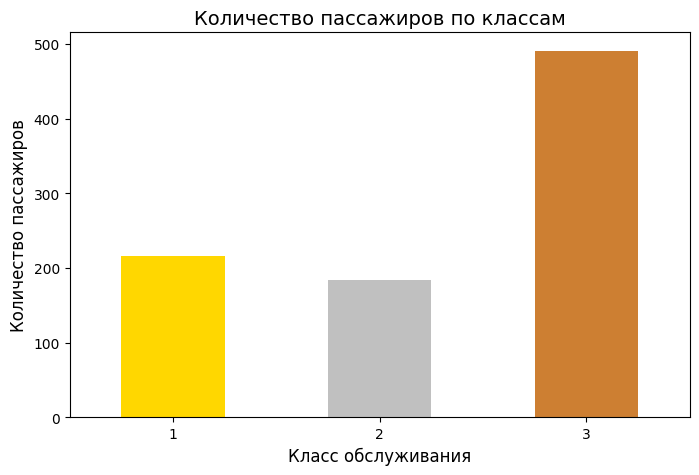

In [21]:
plt.figure(figsize=(8, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color=['#FFD700', '#C0C0C0', '#CD7F32'])
plt.title('Количество пассажиров по классам', fontsize=14)
plt.xlabel('Класс обслуживания', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.xticks(rotation=0)
plt.show()


График выживаемости по полу

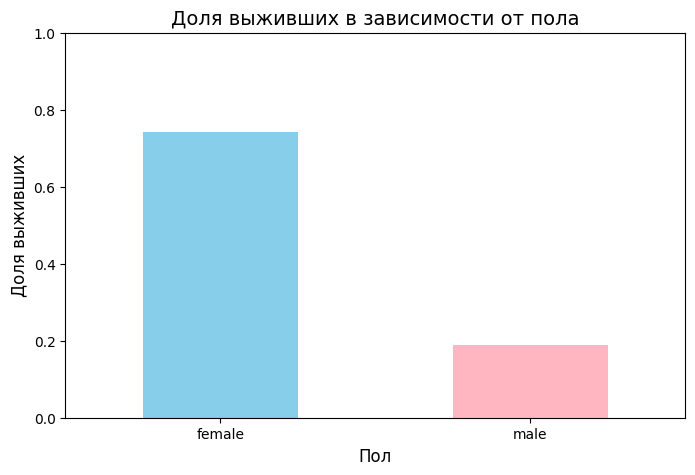

In [22]:
plt.figure(figsize=(8, 5))
survival_by_sex.plot(kind='bar', color=['#87CEEB', '#FFB6C1'])
plt.title('Доля выживших в зависимости от пола', fontsize=14)
plt.xlabel('Пол', fontsize=12)
plt.ylabel('Доля выживших', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

свой вопрос - какой средний возраст у выживших и у погибших пассажиров?


In [23]:
avg_age_by_survival = df.groupby('Survived')['Age'].mean()
avg_age_by_survival.index = ['Погибшие (0)', 'Выжившие (1)']